In [1]:
import os 
os.chdir('D://My_projects//Drug Use//Final Thesis//alcohol')

In [136]:
df=pd.read_csv('W1-4_fulldata.csv')

C:\Users\pc\AppData\Local\Temp\ipykernel_16056\4146512197.py:1: DtypeWarning: Columns (5,123,124,195,197,355,512,521,522,742,744,745,831,832,836,837,838,845,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,955,956,963,968,969,971,975,976,978,980,981,983,999,1024,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1062,1064,1067,1068,1069,1070,1073,1074,1075,1076,1080,1081,1082,1083,1084,1086,1087,1088,1108,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1173,1174,1175,1176,1179,1180,1181,1182,1183,1186,1187,1188,1189,1190,1208,1210,1211,1224,1225,1226,1227,1228,1229,1251,1252,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1289,1291,1372,1373,1379,1395,1396,1397,1398,1399,1400,1422,1423,1424,1425,1426,1427,1428,1429,1430,1431,1432

In [102]:
'AID' in df

True

In [93]:
df2.shape

(2210, 62)

In [42]:
'BuildingType' in df2

True

In [103]:
df['DaysMarijuanaPast12M_W4'].notna().sum()


np.int64(2210)

In [104]:
df_clean = df[df['DaysMarijuanaPast12M_W4'].notna()].copy()


In [105]:
df.shape

(5114, 2961)

In [2]:
import pandas as pd
df2=pd.read_csv('W1-4_fulldata_filtered.csv')

In [3]:
df2 = df2[df2['DaysMarijuanaPast12M_W4'].notna()]

In [4]:
df2=df2.drop(columns=['TotalDrinking'],errors='ignore')

In [ ]:
df_logit=df2.copy()
keep = {
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index",
    "SportsParticipation_Index"
}

cols_to_drop = [
    col for col in df2.columns
    if "index" in col.lower() and col not in keep
]

df_logit = df_logit.drop(columns=cols_to_drop)


In [119]:
cols = list(df2.columns)
for c in cols:
    print(c)


Age when Moved to Current Residence
Race
SleepTrouble_W1
Moodiness_W1
Fearfulness_W1
WeightPerception_W1
LiftWeights_W1
Hours of Sleep
NightAway_W1
SchoolTaught_Smoking_W1
SchoolTaught_Drinking_W1
TimesSkippedSchool
SchoolSuspension
SchoolExpulsion
Trouble_GetAlong_Teachers_W1
Trouble Paying Attention
Trouble_HomeworkCompletion_W1
TroubleGetAlong_Students_W1
SchoolCloseness
Counseling_W1
SelfRatedIntelligence_W1
TroubleConcentrating_W1
FeelingDepressed_W1
TooTiredToDoThings_W1
BirthOrder_W1
MotherEverSmoked_W1
ClosenessToMother_W1
FatherEverSmoked_W1
ClosenessToFather_W1
Mother_Education
Father_Education
ClosenessToMotherAlt_W1
MotherCares_W1
ClosenessToFatherAlt_W1
FatherCares_W1
FriendsRespect_Sex
Rev_FeelGuilty_Sex
Rev_UpsetMother_Sex
Pleasure_Sex
Relax_Sex
Attractive_Sex
LessLonely_Sex
ProudOfYourself_rev
LikeYourself_rev
EverTried_Cigarette
EverSmoked_Regularly
Age_StartedSmoking
Days_SmokedPast30
CigsPerDay_Past30
DrinkWithoutAdults
Age_FirstDrinkNoAdults
DrinkFrequency_Past12mo


In [5]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "DaysMarijuanaPast12M_W4"  
corr_thr = 0.04                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df2.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================

corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df2 = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 95 vars with |corr| ≥ 0.040
[Step 2] Dropped 25 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 70

=== FINAL FEATURE SET ===
Variables kept (n=70):
DisciplinaryIndex
Trouble_GetAlong_Teachers_W1
SchoolBehavior_Index
Sex_Female
GPA_Index
SexAttitudes_Index
FriendsRespect_Sex
Age_FirstMarijuana
Lifetime_Marijuana
Delinquency_Index
PhysicalFight_W1
SoldDrugs_Z
SchoolTrouble_Index_Z
SawViolentAttack_W1
Support_Index
Fight_Serious_Z
NightAway_W1
Rev_UpsetMother_Sex_Z
ClosenessToMother_W1
WeaponThreat_W1
PeerWeed_Count
NotWorthLiving
Relax_Sex
Age_FirstCocaine
TeacherCare_W1
SES_Index
SchoolExpulsion
FriendCare_W1
DrugsAvailable_Home
LessLonely_Sex
GroupFight_Z
BuildingCondition
DroveWithoutPermission_Z
Age_FirstDrinkNoAdults
ExpectCollege_W1
Bills_Payment_Ability
PeerCig_Count
Age at First Drink
DrinksPerOccasion_Past12mo
StreetCondition
Attractive_Sex
HoursGames_W1
Trouble Paying Attention
HoursTV_W1
InjuredSomeone
TroubleGetAlong_Students_W1
ParentCare_W1
Rev_Feel

In [6]:
df2 = df2[df2["DaysMarijuanaPast12M_W4"].notna()].copy()
df2["heavy_smoker"] = (df2["DaysMarijuanaPast12M_W4"] >4 ).astype(int)

y = df2["heavy_smoker"]

X = df2.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


## Cutoff 4

In [99]:
df_logit=df2.copy()
keep = {
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index",
    "SportsParticipation_Index"
}

cols_to_drop = [
    col for col in df2.columns
    if "index" in col.lower() and col not in keep
]

df_logit = df_logit.drop(columns=cols_to_drop)


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [80]:
def hygiene_filter_fit(X_train, min_ones=20):
    drop_cols = []

    # 1) Constant / near-constant
    const_cols = [
        c for c in X_train.columns
        if X_train[c].nunique(dropna=True) <= 1
    ]
    drop_cols.extend(const_cols)

    # 2) Ultra-rare binary variables
    rare_bin = []
    for c in X_train.columns:
        vals = set(X_train[c].dropna().unique())
        if vals.issubset({0, 1}):
            if (X_train[c] == 1).sum() < min_ones:
                rare_bin.append(c)
    drop_cols.extend(rare_bin)

    drop_cols = sorted(set(drop_cols))
    keep_cols = [c for c in X_train.columns if c not in drop_cols]

    return keep_cols, drop_cols


In [81]:
keep_cols, dropped_cols = hygiene_filter_fit(X_train, min_ones=20)

X_train = X_train[keep_cols].copy()
X_test  = X_test[keep_cols].copy()

print(f"Dropped {len(dropped_cols)} hygiene variables")


Dropped 8 hygiene variables


In [82]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = y_train  
corr_thr = 0.04                     # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = X_train.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()



# Ensure target is numeric
if not np.issubdtype(target.dtype, np.number):
    target = pd.to_numeric(target, errors="coerce")



# Candidate predictors
X_cols_all = [c for c in numeric_cols]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all].corrwith(y_train)

corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered X (NO imputation)
# =========================
X_train = df[vars_low_multicollinearity].copy()



[Step 1] Kept 94 vars with |corr| ≥ 0.040
[Step 2] Dropped 25 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 69

=== FINAL FEATURE SET ===
Variables kept (n=69):
DisciplinaryIndex
ClosenessToMother_W1
Trouble_GetAlong_Teachers_W1
SexAttitudes_Index
GPA_Index
FriendsRespect_Sex
LessLonely_Sex
SchoolBehavior_Index
SES_Index
NotWorthLiving_Z
Age_FirstCocaine
Rev_UpsetMother_Sex
SchoolTrouble_Index
Sex_Female
WeaponThreat_W1
Household_Income
PeerCig_Count
Age_FirstMarijuana
SawViolentAttack_W1
Relax_Sex
BuildingCondition
PhysicalFight_W1
Delinquency_Index
Fight_Serious
SchoolExpulsion
NightAway_W1
HouseholdDrinks
NeighborhoodType_3
StreetCondition
DrinkWithoutAdults_Z
Support_Index
AppearedIntoxicated
Bills_Payment_Ability_Z
Mother_Education_Z
TroubleGetAlong_Students_W1
SuicideAttempts
HoursTV_W1
DroveWithoutPermission
SchoolCloseness_Z
TeacherCare_W1
NeighborhoodType_2
Lifetime_Cocaine
Race
Age_FirstDrinkNoAdults
ParentCare_W1
FriendCare_W1
SoldDrugs_Z
Maturity_Female
EverTrie

In [83]:
X_test = X_test.reindex(columns=X_train.columns)


## L2 Logistic

In [233]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression


In [234]:
####4

# Your existing train/test split
X_train2 = X_train.copy()
X_test2  = X_test.copy()



# ============================================================
# 2) PLAIN LOGISTIC REGRESSION (L2), CLASS-WEIGHTED
# ============================================================

pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",    # <<< HANDLE 1:5 IMBALANCE
        max_iter=3000
    ))
])

pipe_lr.fit(X_train2, y_train)

y_pred = pipe_lr.predict_proba(X_test2)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print("=======================================")
print(" LOGISTIC REGRESSION (balanced) AUC:", auc)
print("=======================================")


# ============================================================
# 3) COEFFICIENTS (INTERPRETABLE OUTPUT)
# ============================================================

coef = pipe_lr.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (stronger risk):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective):")
print(coef_df.tail(15))

 LOGISTIC REGRESSION (balanced) AUC: 0.6316681883396376

Top positive coefficients (stronger risk):
                         feature      coef
0              DisciplinaryIndex  0.346645
21                NotWorthLiving  0.280567
6             FriendsRespect_Sex  0.236887
29                LessLonely_Sex  0.201354
34              ExpectCollege_W1  0.170398
1   Trouble_GetAlong_Teachers_W1  0.165695
32      DroveWithoutPermission_Z  0.161763
17         Rev_UpsetMother_Sex_Z  0.161335
22                     Relax_Sex  0.158887
36                 PeerCig_Count  0.144074
16                  NightAway_W1  0.132069
43                    HoursTV_W1  0.129456
69         EverTried_Cigarette_Z  0.127583
59            NeighborhoodType_3  0.125390
13           SawViolentAttack_W1  0.122758

Top negative coefficients (protective):
                          feature      coef
63               Mother_Education -0.103880
7              Age_FirstMarijuana -0.107673
54                           Race -0.11

In [235]:
###4
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

# ============================================================
# 4) CLASSIFICATION METRICS
# ============================================================


from sklearn.metrics import roc_curve

# ============================================================
# 4) CLASSIFICATION METRICS — YOUDEN THRESHOLD
# ============================================================

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Youden’s J
youden_j = tpr - fpr
best_idx = youden_j.argmax()
best_threshold = thresholds[best_idx]

print("Best Threshold (Youden):", round(best_threshold, 3))
print("Best Youden J:", round(youden_j[best_idx], 3))

# Final class predictions
y_pred_class = (y_pred >= best_threshold).astype(int)



print("\n================= METRICS =================")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

print("\nAccuracy:", accuracy_score(y_test, y_pred_class))
print("Precision:", precision_score(y_test, y_pred_class))
print("Recall:", recall_score(y_test, y_pred_class))
print("F1-score:", f1_score(y_test, y_pred_class))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))
print("===========================================")


Best Threshold (Youden): 0.48
Best Youden J: 0.23

================= METRICS =================
Confusion Matrix:
[[294 157]
 [ 43  59]]

Accuracy: 0.6383363471971067
Precision: 0.27314814814814814
Recall: 0.5784313725490197
F1-score: 0.3710691823899371
ROC-AUC: 0.6316681883396376

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.65      0.75       451
           1       0.27      0.58      0.37       102

    accuracy                           0.64       553
   macro avg       0.57      0.62      0.56       553
weighted avg       0.76      0.64      0.68       553



## ElasticNet

In [236]:
###4
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

# ============================================
# 1) REMOVE COLLINEAR FEATURES (>0.85)
# ============================================
X_train2 = X_train.copy()
X_test2  = X_test.copy()

corr = X_train2.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Dropping due to high collinearity:", to_drop)

X_train2 = X_train2.drop(columns=to_drop)
X_test2  = X_test2.drop(columns=to_drop)


# ============================================
# 2) ELASTIC NET LOGISTIC REGRESSION
# ============================================

pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=20,                        # number of C values to test
        cv=5,                         # 5-fold CV
        penalty="elasticnet",
        solver="saga",                # ONLY solver that supports elasticnet
        l1_ratios=[0.1,0.3,0.5,0.7,0.9],
        scoring="roc_auc",            # optimize for AUC
        class_weight="balanced",      # fix imbalance
        max_iter=5000,
        
        n_jobs=-1
    ))
])

pipe_en.fit(X_train2, y_train)

# ============================================
# 3) Evaluate AUC
# ============================================
y_pred = pipe_en.predict_proba(X_test2)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print("=======================================")
print(" Elastic Net Logistic Regression AUC:", auc)
print("=======================================")


# ============================================
# 4) Coefficients
# ============================================
coef = pipe_en.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (risk factors):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective factors):")
print(coef_df.tail(15))


Dropping due to high collinearity: []
 Elastic Net Logistic Regression AUC: 0.67168818747011

Top positive coefficients (risk factors):
                         feature      coef
0              DisciplinaryIndex  0.165505
21                NotWorthLiving  0.131134
1   Trouble_GetAlong_Teachers_W1  0.116203
6             FriendsRespect_Sex  0.113255
59            NeighborhoodType_3  0.101665
29                LessLonely_Sex  0.090180
36                 PeerCig_Count  0.082059
16                  NightAway_W1  0.078024
43                    HoursTV_W1  0.076458
69         EverTried_Cigarette_Z  0.074831
64           AppearedIntoxicated  0.071547
34              ExpectCollege_W1  0.068493
13           SawViolentAttack_W1  0.064060
17         Rev_UpsetMother_Sex_Z  0.062450
32      DroveWithoutPermission_Z  0.062201

Top negative coefficients (protective factors):
                          feature      coef
46                  ParentCare_W1 -0.035118
55           MentalDistress_Index -0.03

In [237]:
###4
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc
)
import numpy as np

# ============================================
# 1. Get predicted probabilities
# ============================================
y_pred_prob = pipe_en.predict_proba(X_test2)[:, 1]

# ============================================
# 2. Basic metrics at threshold = 0.5
# ============================================
y_pred_class = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_class)
prec = precision_score(y_test, y_pred_class, zero_division=0)
rec = recall_score(y_test, y_pred_class, zero_division=0)
f1 = f1_score(y_test, y_pred_class, zero_division=0)
auc_roc = roc_auc_score(y_test, y_pred_prob)

print("===============================================")
print(" METRICS (Threshold = 0.50)")
print("===============================================")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

# ============================================
# 3. Precision-Recall AUC
# ============================================
prec_curve, rec_curve, thresh = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(rec_curve, prec_curve)

print("\nPrecision-Recall AUC:", round(pr_auc, 4))

from sklearn.metrics import roc_curve
import numpy as np

# ============================================
# 4. Find BEST YOUDEN threshold
# ============================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print("\n===============================================")
print(f" BEST YOUDEN Threshold: {best_threshold:.4f}")
print(f" BEST Youden J: {youden_j[best_idx]:.4f}")
print("===============================================")


# Recompute metrics at best threshold
y_best = (y_pred_prob >= best_threshold).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_best, zero_division=0))
best_acc = accuracy_score(y_test, y_best)
best_prec = precision_score(y_test, y_best, zero_division=0)
best_rec = recall_score(y_test, y_best, zero_division=0)
best_f1 = f1_score(y_test, y_best, zero_division=0)

print("\nMetrics at BEST F1 Threshold:")
print(f"Accuracy:  {best_acc:.4f}")
print(f"Precision: {best_prec:.4f}")
print(f"Recall:    {best_rec:.4f}")
print(f"F1 Score:  {best_f1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_best))

 METRICS (Threshold = 0.50)
Accuracy:  0.6763
Precision: 0.3026
Recall:    0.5784
F1 Score:  0.3973
AUC-ROC:   0.6717

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       451
           1       0.30      0.58      0.40       102

    accuracy                           0.68       553
   macro avg       0.59      0.64      0.59       553
weighted avg       0.77      0.68      0.71       553

Confusion Matrix:
[[315 136]
 [ 43  59]]

Precision-Recall AUC: 0.3065

 BEST YOUDEN Threshold: 0.4947
 BEST Youden J: 0.3082

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77       451
           1       0.31      0.63      0.41       102

    accuracy                           0.67       553
   macro avg       0.60      0.65      0.59       553
weighted avg       0.78      0.67      0.71       553


Metrics at BEST F1 Threshold:
Accuracy:  0.6709
Preci

## RandomForest 

In [239]:
###4
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [300, 500, 800, 1200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features': ['sqrt', 'log2', 0.5, None],
    'class_weight': ['balanced', 'balanced_subsample']
}

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',     # optimize minority detection
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Running RandomizedSearchCV...")
rs.fit(X_train2, y_train)

print("\nBest Parameters:")
print(rs.best_params_)

# Use best found model
best_rf = rs.best_estimator_

# ============================================================
# 5. PREDICT PROBABILITIES
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

y_prob = best_rf.predict_proba(X_test2)[:, 1]

# ============================================================
# 6. FIND BEST THRESHOLD
# ============================================================

from sklearn.metrics import roc_curve
import numpy as np

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_prob)
# Youden's J statistic
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)

best_t = thresholds[best_idx]
best_j = youden_j[best_idx]

print(f"\nBest threshold (Youden): {best_t:.3f}")
print(f"Best Youden J: {best_j:.3f}")


# ============================================================
# 7. FINAL EVALUATION WITH OPTIMAL THRESHOLD
# ============================================================

y_pred = (y_prob >= best_t).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_prob))

Running RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Parameters:
{'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced'}

Best threshold (Youden): 0.308
Best Youden J: 0.295

Confusion Matrix:
[[239 212]
 [ 24  78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.53      0.67       451
           1       0.27      0.76      0.40       102

    accuracy                           0.57       553
   macro avg       0.59      0.65      0.53       553
weighted avg       0.79      0.57      0.62       553

AUC: 0.6713186383200731


In [240]:
import pandas as pd
import numpy as np

# Get importances
importances = best_rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X_train2.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_imp.head(30))   # top 30 most important features


                         feature  importance
25                     SES_Index    0.046998
48              Household_Income    0.046827
5             SexAttitudes_Index    0.042137
2           SchoolBehavior_Index    0.041317
4                      GPA_Index    0.040870
9              Delinquency_Index    0.035418
43                    HoursTV_W1    0.033516
38    DrinksPerOccasion_Past12mo    0.028422
14                 Support_Index    0.027065
63              Mother_Education    0.025782
37            Age at First Drink    0.025093
12         SchoolTrouble_Index_Z    0.024933
1   Trouble_GetAlong_Teachers_W1    0.023627
8             Lifetime_Marijuana    0.022376
17         Rev_UpsetMother_Sex_Z    0.019883
33        Age_FirstDrinkNoAdults    0.019739
55          MentalDistress_Index    0.019455
0              DisciplinaryIndex    0.019061
41                 HoursGames_W1    0.017740
6             FriendsRespect_Sex    0.017142
49     ParentalSupervision_Index    0.017085
29        

## Catboost

In [263]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import numpy as np

cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

param_dist_cat = {
    "iterations": [400, 800, 1200, 1600],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9, 12, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5, 10],
    # If you're using class weights, tune them lightly OR set fixed below
    "class_weights": [[1, 3], [1, 5], [1, 7], [1, 10]]
}

rs_cat = RandomizedSearchCV(
    cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Running CatBoost RandomizedSearchCV...")
rs_cat.fit(X_train2, y_train)

print("\nBest Parameters (CatBoost):")
print(rs_cat.best_params_)

best_cat = rs_cat.best_estimator_

# Predict probabilities
y_prob_cat = best_cat.predict_proba(X_test2)[:, 1]

# Youden threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cat)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_t = thresholds[best_idx]

print(f"\nBest threshold (Youden): {best_t:.3f}")

# Final evaluation
y_pred_cat = (y_prob_cat >= best_t).astype(int)

print("\nConfusion Matrix (CatBoost):")
print(confusion_matrix(y_test, y_pred_cat))

print("\nClassification Report (CatBoost):")
print(classification_report(y_test, y_pred_cat))

print("AUC (CatBoost):", roc_auc_score(y_test, y_prob_cat))


Running CatBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Parameters (CatBoost):
{'subsample': 0.7, 'random_strength': 1, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 400, 'depth': 10, 'class_weights': [1, 3]}

Best threshold (Youden): 0.268

Confusion Matrix (CatBoost):
[[277 174]
 [ 36  66]]

Classification Report (CatBoost):
              precision    recall  f1-score   support

           0       0.88      0.61      0.73       451
           1       0.28      0.65      0.39       102

    accuracy                           0.62       553
   macro avg       0.58      0.63      0.56       553
weighted avg       0.77      0.62      0.66       553

AUC (CatBoost): 0.64812399460893


## XGBoost

In [11]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import numpy as np
X_train2=X_train.copy()
X_test2=X_test.copy()
# Compute imbalance ratio for scale_pos_weight
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = neg / pos

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos
)

param_dist_xgb = {
    "n_estimators": [300, 500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1]
}

rs_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Running XGBoost RandomizedSearchCV...")
rs_xgb.fit(X_train2, y_train)

print("\nBest Parameters (XGBoost):")
print(rs_xgb.best_params_)

best_xgb = rs_xgb.best_estimator_

# Predict probabilities
y_prob_xgb = best_xgb.predict_proba(X_test2)[:, 1]

# Youden threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_t = thresholds[best_idx]

print(f"\nBest threshold (Youden): {best_t:.3f}")

# Final evaluation
y_pred_xgb = (y_prob_xgb >= best_t).astype(int)

print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

print("AUC (XGBoost):", roc_auc_score(y_test, y_prob_xgb))


Running XGBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Parameters (XGBoost):
{'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 8, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 2, 'colsample_bytree': 0.8}

Best threshold (Youden): 0.361

Confusion Matrix (XGBoost):
[[279 172]
 [ 32  70]]

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.90      0.62      0.73       451
           1       0.29      0.69      0.41       102

    accuracy                           0.63       553
   macro avg       0.59      0.65      0.57       553
weighted avg       0.78      0.63      0.67       553

AUC (XGBoost): 0.6722099039172209


X_bg_np dtype: float32
X_test_np dtype: float32


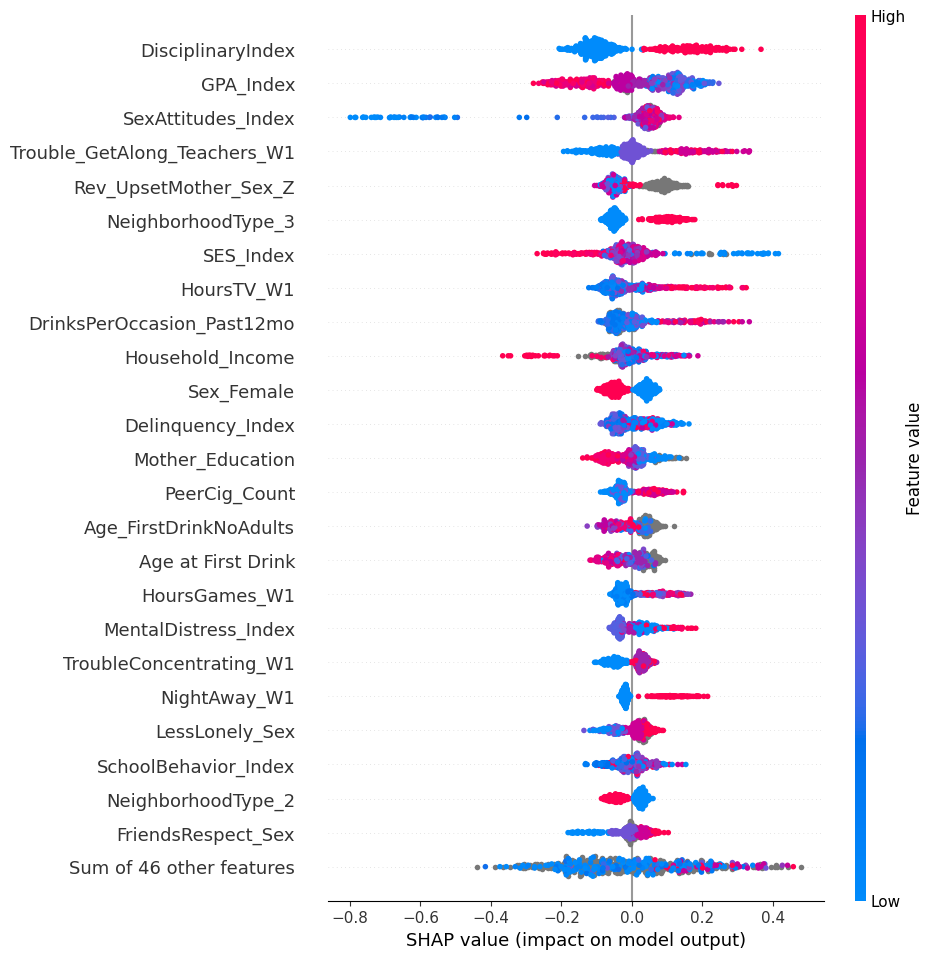

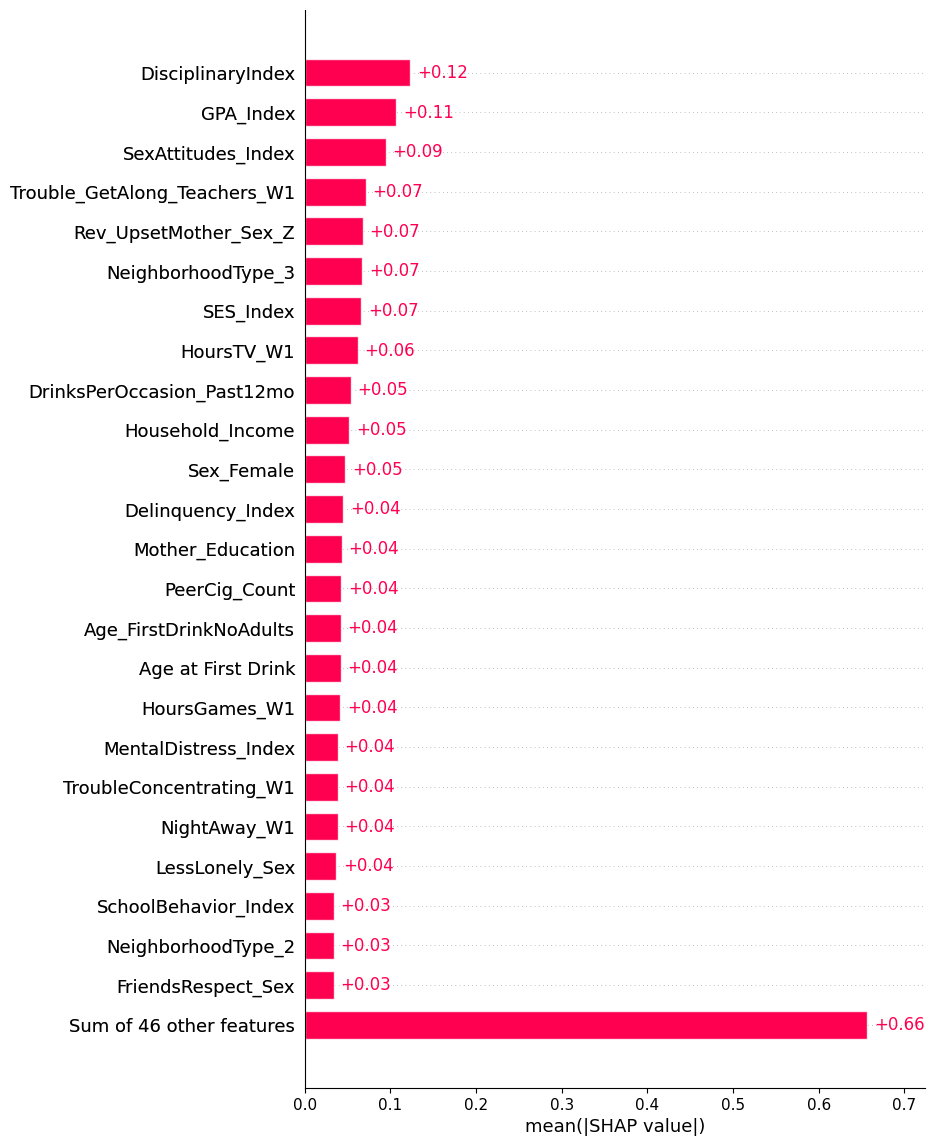

Top SHAP features: ['DisciplinaryIndex', 'GPA_Index', 'SexAttitudes_Index', 'Trouble_GetAlong_Teachers_W1', 'Rev_UpsetMother_Sex_Z', 'NeighborhoodType_3', 'SES_Index', 'HoursTV_W1', 'DrinksPerOccasion_Past12mo', 'Household_Income']


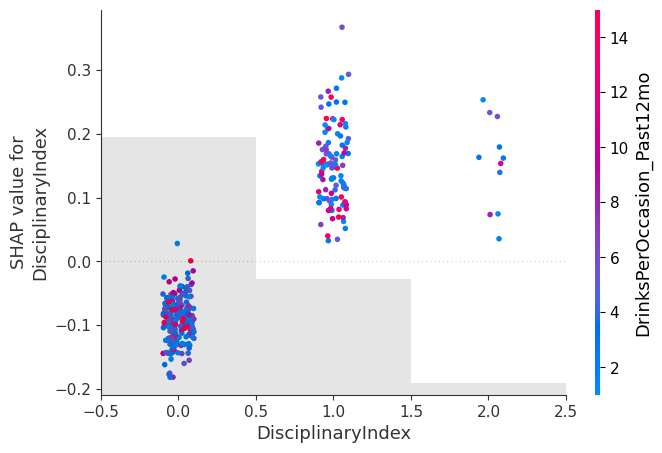

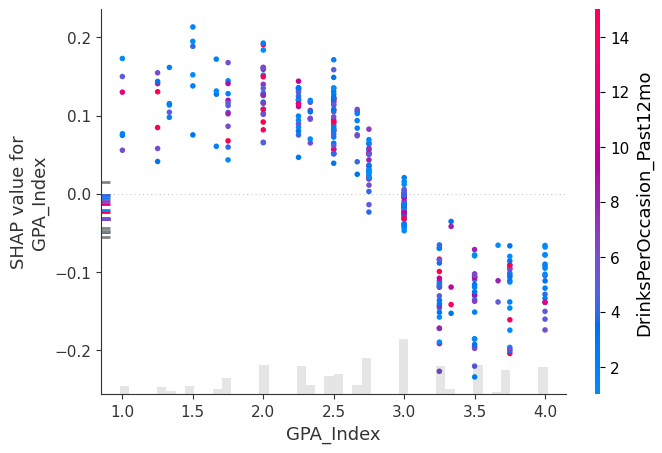

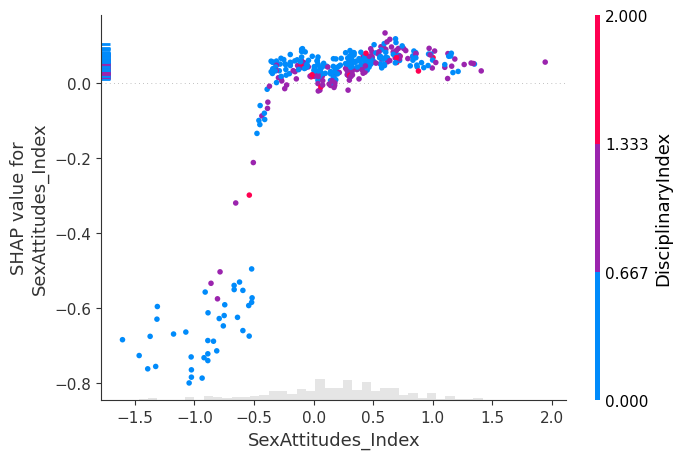

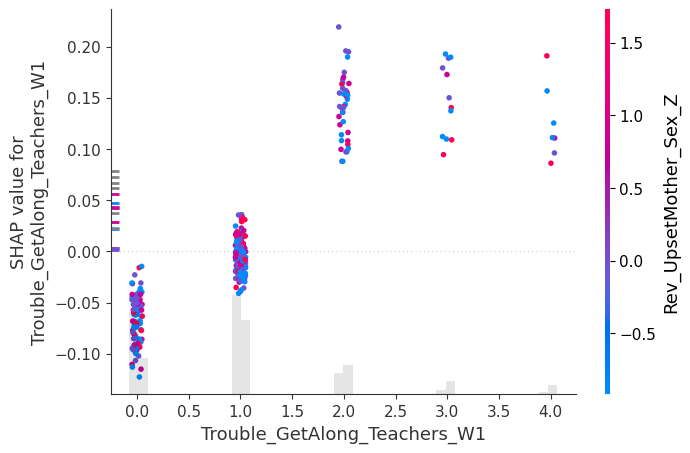

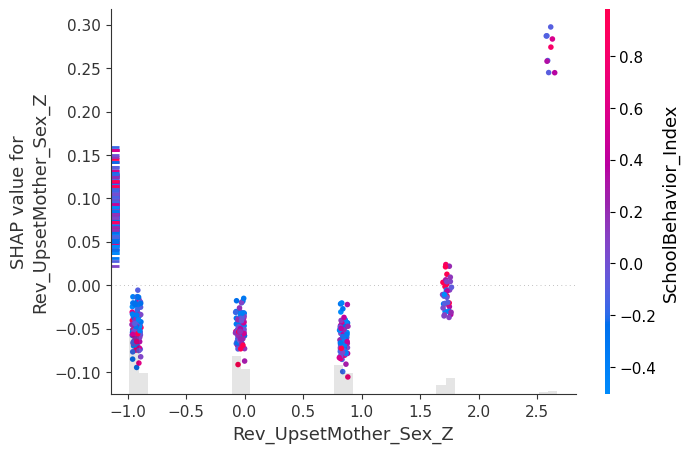

Explaining test row index: 502


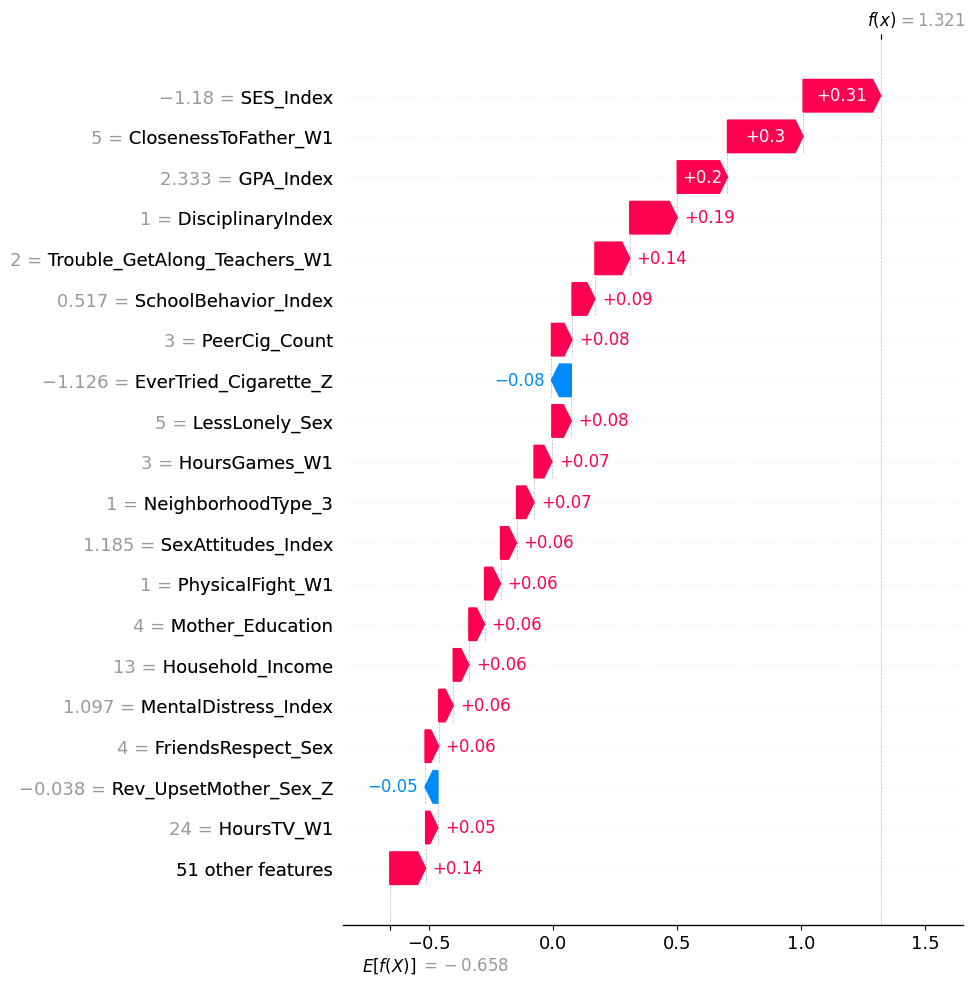

In [13]:
# ============================
# SHAP analysis for best_xgb
# ============================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
X_train_xgb=X_train.copy()
X_test_xgb=X_test.copy()
# 0) Make sure X_* are DataFrames (keeps feature names for plots)
if not isinstance(X_train_xgb, pd.DataFrame):
    X_train_xgb = pd.DataFrame(X_train_xgb)
if not isinstance(X_test_xgb, pd.DataFrame):
    X_test_xgb = pd.DataFrame(X_test_xgb)

# (Optional but recommended) background sample for speed/stability
bg_size = min(500, len(X_train_xgb))
X_bg = X_train_xgb.sample(bg_size, random_state=42)


import numpy as np
import shap

feature_names = X_train_xgb.columns.tolist()

# 1) Convert bool -> int, then force everything to float32
def force_float32(df):
    df = df.copy()
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int8)
    return df.astype(np.float32)

X_train_shap = force_float32(X_train_xgb)
X_test_shap  = force_float32(X_test_xgb)

# 2) Background sample
bg_size = min(200, len(X_train_shap))
X_bg = X_train_shap.sample(bg_size, random_state=42)

# 3) Convert to numpy float32 (NOW it won't be object)
X_bg_np   = X_bg.to_numpy(dtype=np.float32)
X_test_np = X_test_shap.to_numpy(dtype=np.float32)

print("X_bg_np dtype:", X_bg_np.dtype)
print("X_test_np dtype:", X_test_np.dtype)

# 4) SHAP
explainer = shap.Explainer(best_xgb, X_bg_np, feature_names=feature_names)
shap_values = explainer(X_test_np)

shap.plots.beeswarm(shap_values, max_display=25)




# (Alternative global view: mean(|SHAP|) bar)
shap.plots.bar(shap_values, max_display=25)

# ---------------------------------------------------------
# B) DEPENDENCE: top features (scatter plots)
# ---------------------------------------------------------
# Get top features by mean absolute SHAP
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
top_features = X_test_xgb.columns[top_idx].tolist()

print("Top SHAP features:", top_features)

# Dependence plots for top features
for feat in top_features[:5]:
    shap.plots.scatter(shap_values[:, feat], color=shap_values)

# ---------------------------------------------------------
# C) LOCAL: explain a single prediction
# ---------------------------------------------------------
# Choose an instance index (e.g., highest predicted risk)
idx = int(np.argmax(best_xgb.predict_proba(X_test_xgb)[:, 1]))
print("Explaining test row index:", idx)

# Waterfall plot for that instance
shap.plots.waterfall(shap_values[idx], max_display=20)

# Force plot (interactive in notebooks; may need JS init)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx, :],
    X_test_xgb.iloc[idx, :],
)

# ---------------------------------------------------------
# D) (Optional) SHAP values table export
# ---------------------------------------------------------
shap_df = pd.DataFrame(shap_values.values, columns=X_test_xgb.columns)
shap_df["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]
shap_df["y_true"] = np.array(y_test)

# Save if you want
# shap_df.to_csv("shap_values_test.csv", index=False)


In [20]:
# SHAP values array: (n_samples, n_features)
S = shap_values.values

# Optional but recommended: standardize
from sklearn.preprocessing import StandardScaler
S_scaled = StandardScaler().fit_transform(S)


In [21]:
from sklearn.cluster import KMeans

k = 3  # start here
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
archetypes = kmeans.fit_predict(S_scaled)


In [22]:
df_archetypes = X_test_xgb.copy()
df_archetypes["archetype"] = archetypes
df_archetypes["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]


In [23]:
import pandas as pd
import numpy as np

archetype_profiles = (
    pd.DataFrame(S, columns=feature_names)
      .assign(archetype=archetypes)
      .groupby("archetype")
      .mean()
)

archetype_profiles


,DisciplinaryIndex,Trouble_GetAlong_Teachers_W1,SchoolBehavior_Index,Sex_Female,GPA_Index,SexAttitudes_Index,FriendsRespect_Sex,Age_FirstMarijuana,Lifetime_Marijuana,Delinquency_Index,...,HangoutFriends_W1,TroubleConcentrating_W1,ClosenessToFather_W1,Mother_Education,AppearedIntoxicated,WantLeaveHome_W1,DrinkWithoutAdults_Z,WorkedForPay_W1,NeighborhoodType_2,EverTried_Cigarette_Z
archetype,,,,,,,,,,,,,,,,,,,,,
0,0.077153,0.052060,0.013507,0.010030,0.052860,0.036115,0.008577,0.010832,0.011696,0.011923,...,0.003414,0.010422,-0.002989,0.016353,0.0,0.007925,0.003933,-0.000356,-0.003307,0.009402
1,-0.051067,0.006407,-0.010258,-0.003776,-0.024240,0.049132,0.003673,-0.003276,-0.002435,0.004338,...,-0.000084,-0.010646,-0.008845,-0.008701,0.0,-0.017795,0.002940,0.002133,0.003346,-0.017750
2,-0.042976,-0.010913,-0.005179,-0.012467,0.003189,-0.078872,-0.018130,0.000067,-0.010200,-0.005763,...,-0.000213,-0.002251,-0.008728,-0.021549,0.0,-0.000750,0.008758,-0.002864,-0.001557,0.006553



Archetype 0


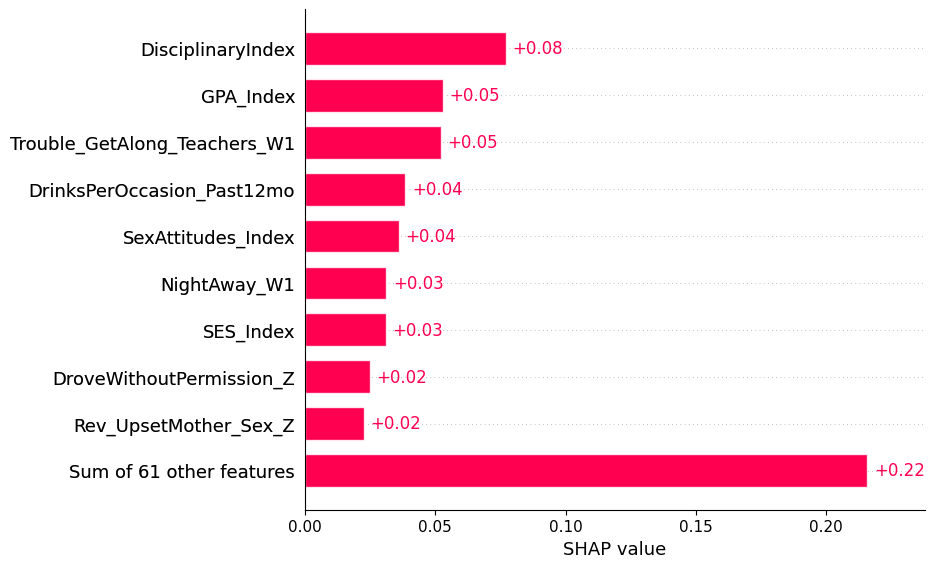


Archetype 1


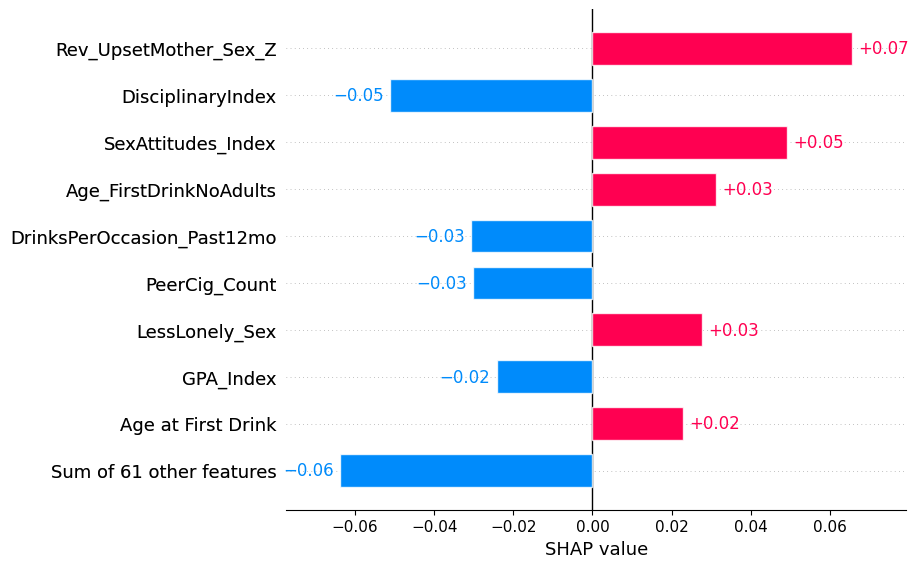


Archetype 2


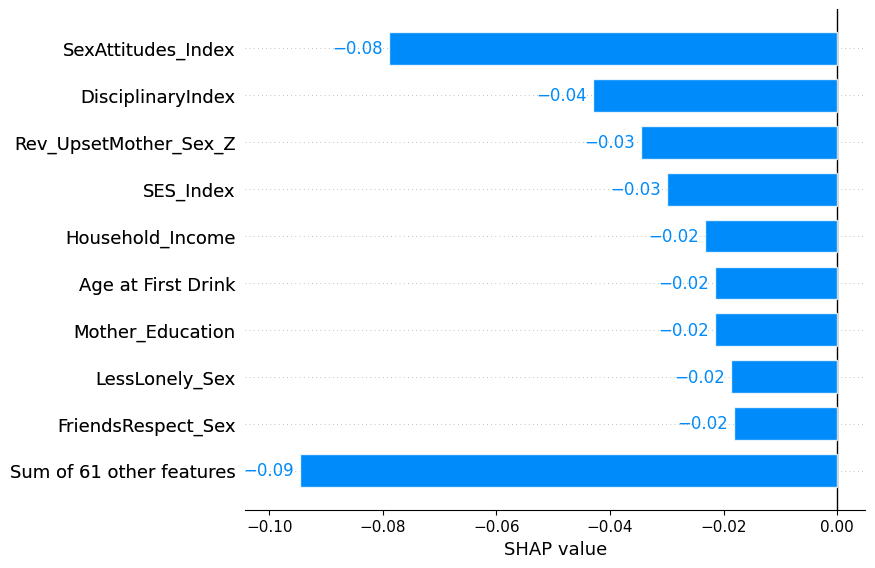

In [24]:
for a in sorted(df_archetypes["archetype"].unique()):
    print(f"\nArchetype {a}")
    shap.plots.bar(
        shap.Explanation(
            values=archetype_profiles.loc[a].values,
            feature_names=feature_names
        ),
        max_display=10
    )


In [25]:
df_archetypes.groupby("archetype")["pred_prob"].describe()


,count,mean,std,min,25%,50%,75%,max
archetype,,,,,,,,
0,148.0,0.482030,0.108835,0.233714,0.407122,0.477942,0.564681,0.789360
1,183.0,0.349812,0.119260,0.119396,0.255748,0.332429,0.430014,0.657739
2,222.0,0.271944,0.096591,0.092031,0.199225,0.267521,0.333912,0.571584


## cutoff 3

In [34]:
df2 = df2[df2["DaysMarijuanaPast12M_W4"].notna()].copy()
df2["heavy_smoker"] = (df2["DaysMarijuanaPast12M_W4"] >3 ).astype(int)

y = df2["heavy_smoker"]

X = df2.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


## L2 Logistic

In [170]:
####3

# Your existing train/test split
X_train2 = X_train.copy()
X_test2  = X_test.copy()


# ============================================================
# 1) REMOVE COLLINEAR FEATURES (>0.85)
# (This step is still important for plain LR)
# ============================================================

corr = X_train2.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Dropping due to high collinearity:", to_drop)

X_train2 = X_train2.drop(columns=to_drop)
X_test2  = X_test2.drop(columns=to_drop)


# ============================================================
# 2) PLAIN LOGISTIC REGRESSION (L2), CLASS-WEIGHTED
# ============================================================

pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",    # <<< HANDLE 1:5 IMBALANCE
        max_iter=3000
    ))
])

pipe_lr.fit(X_train2, y_train)

y_pred = pipe_lr.predict_proba(X_test2)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print("=======================================")
print(" LOGISTIC REGRESSION (balanced) AUC:", auc)
print("=======================================")


# ============================================================
# 3) COEFFICIENTS (INTERPRETABLE OUTPUT)
# ============================================================

coef = pipe_lr.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (stronger risk):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective):")
print(coef_df.tail(15))

Dropping due to high collinearity: []
 LOGISTIC REGRESSION (balanced) AUC: 0.6433404940923739

Top positive coefficients (stronger risk):
                         feature      coef
0              DisciplinaryIndex  0.200079
6             FriendsRespect_Sex  0.169988
17         Rev_UpsetMother_Sex_Z  0.165762
22                     Relax_Sex  0.134233
40                Attractive_Sex  0.131805
52              SuicidalIdeation  0.129569
28           DrugsAvailable_Home  0.116827
69         EverTried_Cigarette_Z  0.111215
36                 PeerCig_Count  0.109416
34              ExpectCollege_W1  0.106658
10              PhysicalFight_W1  0.105904
1   Trouble_GetAlong_Teachers_W1  0.103732
14                 Support_Index  0.103215
49     ParentalSupervision_Index  0.102696
21                NotWorthLiving  0.098762

Top negative coefficients (protective):
                  feature      coef
46          ParentCare_W1 -0.070993
18   ClosenessToMother_W1 -0.075163
41          HoursGames_W1

In [171]:
###3
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

# ============================================================
# 4) CLASSIFICATION METRICS
# ============================================================


from sklearn.metrics import roc_curve

# ============================================================
# 4) CLASSIFICATION METRICS — YOUDEN THRESHOLD
# ============================================================

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Youden’s J
youden_j = tpr - fpr
best_idx = youden_j.argmax()
best_threshold = thresholds[best_idx]

print("Best Threshold (Youden):", round(best_threshold, 3))
print("Best Youden J:", round(youden_j[best_idx], 3))

# Final class predictions
y_pred_class = (y_pred >= best_threshold).astype(int)



print("\n================= METRICS =================")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

print("\nAccuracy:", accuracy_score(y_test, y_pred_class))
print("Precision:", precision_score(y_test, y_pred_class))
print("Recall:", recall_score(y_test, y_pred_class))
print("F1-score:", f1_score(y_test, y_pred_class))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))
print("===========================================")


Best Threshold (Youden): 0.48
Best Youden J: 0.255

================= METRICS =================
Confusion Matrix:
[[246 174]
 [ 44  89]]

Accuracy: 0.6057866184448463
Precision: 0.33840304182509506
Recall: 0.6691729323308271
F1-score: 0.4494949494949495
ROC-AUC: 0.6433404940923739

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.59      0.69       420
           1       0.34      0.67      0.45       133

    accuracy                           0.61       553
   macro avg       0.59      0.63      0.57       553
weighted avg       0.73      0.61      0.63       553



## ElasticNet

In [36]:
###3
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

# ============================================
# 1) REMOVE COLLINEAR FEATURES (>0.85)
# ============================================
X_train2 = X_train.copy()
X_test2  = X_test.copy()




# ============================================
# 2) ELASTIC NET LOGISTIC REGRESSION
# ============================================

pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=20,                        # number of C values to test
        cv=5,                         # 5-fold CV
        penalty="elasticnet",
        solver="saga",                # ONLY solver that supports elasticnet
        l1_ratios=[0.1,0.3,0.5,0.7,0.9],
        scoring="roc_auc",            # optimize for AUC
        class_weight="balanced",      # fix imbalance
        max_iter=5000,
        
        n_jobs=-1
    ))
])

pipe_en.fit(X_train2, y_train)

# ============================================
# 3) Evaluate AUC
# ============================================
y_pred = pipe_en.predict_proba(X_test2)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print("=======================================")
print(" Elastic Net Logistic Regression AUC:", auc)
print("=======================================")


# ============================================
# 4) Coefficients
# ============================================
coef = pipe_en.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (risk factors):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective factors):")
print(coef_df.tail(15))


 Elastic Net Logistic Regression AUC: 0.6762799856784818

Top positive coefficients (risk factors):
                         feature      coef
0              DisciplinaryIndex  0.085512
28           DrugsAvailable_Home  0.066443
1   Trouble_GetAlong_Teachers_W1  0.062479
10              PhysicalFight_W1  0.052142
6             FriendsRespect_Sex  0.051419
52              SuicidalIdeation  0.049127
36                 PeerCig_Count  0.041627
21                NotWorthLiving  0.035887
49     ParentalSupervision_Index  0.029834
17         Rev_UpsetMother_Sex_Z  0.027588
69         EverTried_Cigarette_Z  0.026537
59            NeighborhoodType_3  0.023313
26               SchoolExpulsion  0.016959
23              Age_FirstCocaine  0.015033
5             SexAttitudes_Index  0.014710

Top negative coefficients (protective factors):
                  feature      coef
55   MentalDistress_Index  0.000000
37     Age at First Drink -0.000627
18   ClosenessToMother_W1 -0.014958
7      Age_FirstMar

In [37]:
###3
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, auc
)
import numpy as np

# ============================================
# 1. Get predicted probabilities
# ============================================
y_pred_prob = pipe_en.predict_proba(X_test2)[:, 1]

# ============================================
# 2. Basic metrics at threshold = 0.5
# ============================================
y_pred_class = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_class)
prec = precision_score(y_test, y_pred_class, zero_division=0)
rec = recall_score(y_test, y_pred_class, zero_division=0)
f1 = f1_score(y_test, y_pred_class, zero_division=0)
auc_roc = roc_auc_score(y_test, y_pred_prob)

print("===============================================")
print(" METRICS (Threshold = 0.50)")
print("===============================================")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

# ============================================
# 3. Precision-Recall AUC
# ============================================
prec_curve, rec_curve, thresh = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(rec_curve, prec_curve)

print("\nPrecision-Recall AUC:", round(pr_auc, 4))

from sklearn.metrics import roc_curve
import numpy as np

# ============================================
# 4. Find BEST YOUDEN threshold
# ============================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print("\n===============================================")
print(f" BEST YOUDEN Threshold: {best_threshold:.4f}")
print(f" BEST Youden J: {youden_j[best_idx]:.4f}")
print("===============================================")


# Recompute metrics at best threshold
y_best = (y_pred_prob >= best_threshold).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_best, zero_division=0))
best_acc = accuracy_score(y_test, y_best)
best_prec = precision_score(y_test, y_best, zero_division=0)
best_rec = recall_score(y_test, y_best, zero_division=0)
best_f1 = f1_score(y_test, y_best, zero_division=0)

print("\nMetrics at BEST F1 Threshold:")
print(f"Accuracy:  {best_acc:.4f}")
print(f"Precision: {best_prec:.4f}")
print(f"Recall:    {best_rec:.4f}")
print(f"F1 Score:  {best_f1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_best))

 METRICS (Threshold = 0.50)
Accuracy:  0.6239
Precision: 0.3431
Recall:    0.6165
F1 Score:  0.4409
AUC-ROC:   0.6763

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.63      0.72       420
           1       0.34      0.62      0.44       133

    accuracy                           0.62       553
   macro avg       0.59      0.62      0.58       553
weighted avg       0.72      0.62      0.65       553

Confusion Matrix:
[[263 157]
 [ 51  82]]

Precision-Recall AUC: 0.378

 BEST YOUDEN Threshold: 0.4823
 BEST Youden J: 0.3059

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.57      0.69       420
           1       0.35      0.74      0.48       133

    accuracy                           0.61       553
   macro avg       0.61      0.65      0.58       553
weighted avg       0.75      0.61      0.64       553


Metrics at BEST F1 Threshold:
Accuracy:  0.6094
Precis

In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# -----------------------------
# 0) Get feature names safely
# -----------------------------
if isinstance(X_train2, pd.DataFrame):
    feature_names = X_train2.columns.to_list()
else:
    feature_names = [f"x{i}" for i in range(X_train2.shape[1])]

# -----------------------------
# 1) Extract fitted coefficients from pipe_en
# -----------------------------
# If your final estimator step name is not "lr", change it below
# (e.g., "logreg", "clf", etc.)
final_step_name = list(pipe_en.named_steps.keys())[-1]
clf = pipe_en.named_steps[final_step_name]

coefs = clf.coef_.ravel()
intercept = float(clf.intercept_.ravel()[0]) if hasattr(clf, "intercept_") else np.nan

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs),
    "odds_ratio": np.exp(coefs)
}).sort_values("abs_coef", ascending=False)

print("\n==============================")
print("ELASTIC NET — COEFFICIENTS")
print("==============================")
print("Intercept:", intercept)

print("\nTop 20 by |coef|:")
print(coef_df.head(20).to_string(index=False))

print("\nTop 10 POSITIVE (increase odds of class=1):")
print(coef_df.sort_values("coef", ascending=False).head(10).to_string(index=False))

print("\nTop 10 NEGATIVE (decrease odds of class=1):")
print(coef_df.sort_values("coef", ascending=True).head(10).to_string(index=False))

# -----------------------------
# 2) Stability / Selection frequency across folds
#    (how often each feature gets non-zero coef)
# -----------------------------
# We refit the same pipeline across CV folds and track non-zero coefficients and sign consistency.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selected_counts = np.zeros(len(feature_names), dtype=int)
pos_counts = np.zeros(len(feature_names), dtype=int)
neg_counts = np.zeros(len(feature_names), dtype=int)

# If X_train2 is DataFrame, we can index rows with iloc; otherwise, use array slicing
is_df = isinstance(X_train2, pd.DataFrame)

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train2, y_train), 1):
    model = clone(pipe_en)

    if is_df:
        X_tr, y_tr = X_train2.iloc[tr_idx], y_train.iloc[tr_idx] if hasattr(y_train, "iloc") else y_train[tr_idx]
    else:
        X_tr, y_tr = X_train2[tr_idx], y_train[tr_idx]

    model.fit(X_tr, y_tr)

    step_name = list(model.named_steps.keys())[-1]
    m = model.named_steps[step_name]
    c = m.coef_.ravel()

    nz = (np.abs(c) > 1e-12)
    selected_counts += nz.astype(int)
    pos_counts += (c >  1e-12).astype(int)
    neg_counts += (c < -1e-12).astype(int)

stability_df = pd.DataFrame({
    "feature": feature_names,
    "selected_in_folds": selected_counts,
    "selection_rate": selected_counts / cv.get_n_splits(),
    "pos_rate_given_selected": np.where(selected_counts > 0, pos_counts / selected_counts, 0.0),
    "neg_rate_given_selected": np.where(selected_counts > 0, neg_counts / selected_counts, 0.0),
    "final_coef": coefs,
    "final_odds_ratio": np.exp(coefs)
}).sort_values(["selection_rate", "selected_in_folds"], ascending=False)

print("\n========================================")
print("ELASTIC NET — STABILITY (5-FOLD CV)")
print("========================================")
print("Top 25 most stable (highest selection rate):")
print(stability_df.head(25).to_string(index=False))

# Optional: stable + strong list
stable_strong = stability_df[
    (stability_df["selection_rate"] >= 0.8) & (np.abs(stability_df["final_coef"]) > 0)
].copy()

print("\nStable + non-zero in final model (selection_rate >= 0.8):")
if len(stable_strong) == 0:
    print("None (or threshold too strict).")
else:
    print(stable_strong.sort_values("abs_final", ascending=False) if "abs_final" in stable_strong.columns else stable_strong.to_string(index=False))

# -----------------------------
# 3) Linear “contribution” sanity check on TEST set
#    contribution_i = coef_i * x_i  (for standardized/scaled features)
#    This is NOT SHAP; it's exact linear attribution under the model.
# -----------------------------
# Get transformed (post-preprocessing) matrix that the classifier actually sees
# Works if your pipeline includes scaler/transformers. If pipeline has no transform, it's X itself.
X_test_trans = pipe_en[:-1].transform(X_test2) if len(pipe_en.steps) > 1 else X_test2

# If transform returns numpy array, we can compute contributions
contrib = X_test_trans * coefs  # shape: (n_samples, n_features)
mean_abs_contrib = np.mean(np.abs(contrib), axis=0)

contrib_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_contribution": mean_abs_contrib,
    "coef": coefs,
    "odds_ratio": np.exp(coefs),
}).sort_values("mean_abs_contribution", ascending=False)

print("\n========================================")
print("ELASTIC NET — MEAN |LINEAR CONTRIBUTION| (TEST)")
print("========================================")
print(contrib_df.head(25).to_string(index=False))

# Optional: show top drivers for ONE particular test instance (e.g., first row)
idx = 0
row_contrib = pd.DataFrame({
    "feature": feature_names,
    "x_value": X_test_trans[idx],
    "coef": coefs,
    "contribution": contrib[idx]
}).assign(abs_contribution=lambda d: np.abs(d["contribution"])) \
  .sort_values("abs_contribution", ascending=False)

print(f"\nTop 15 contributors for test instance #{idx}:")
print(row_contrib.head(15).to_string(index=False))


ELASTIC NET — COEFFICIENTS
Intercept: -0.06064220032514285

Top 20 by |coef|:
                     feature      coef  abs_coef  odds_ratio
                  Sex_Female -0.123133  0.123133    0.884146
           DisciplinaryIndex  0.085512  0.085512    1.089274
            Household_Income -0.071571  0.071571    0.930930
         DrugsAvailable_Home  0.066443  0.066443    1.068700
Trouble_GetAlong_Teachers_W1  0.062479  0.062479    1.064472
        DrinkWithoutAdults_Z -0.059015  0.059015    0.942693
               FriendCare_W1 -0.056208  0.056208    0.945343
            PhysicalFight_W1  0.052142  0.052142    1.053526
          FriendsRespect_Sex  0.051419  0.051419    1.052764
            SuicidalIdeation  0.049127  0.049127    1.050354
          NeighborhoodType_6 -0.042739  0.042739    0.958162
               PeerCig_Count  0.041627  0.041627    1.042506
                        Race -0.039245  0.039245    0.961515
              NotWorthLiving  0.035887  0.035887    1.036539
      

C:\Users\pc\AppData\Local\Temp\ipykernel_12500\1565612818.py:83: RuntimeWarning: invalid value encountered in divide
  "pos_rate_given_selected": np.where(selected_counts > 0, pos_counts / selected_counts, 0.0),
C:\Users\pc\AppData\Local\Temp\ipykernel_12500\1565612818.py:84: RuntimeWarning: invalid value encountered in divide
  "neg_rate_given_selected": np.where(selected_counts > 0, neg_counts / selected_counts, 0.0),


## RandomForest

In [175]:
###3
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [300, 500, 800, 1200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features': ['sqrt', 'log2', 0.5, None],
    'class_weight': ['balanced', 'balanced_subsample']
}

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',     # optimize minority detection
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Running RandomizedSearchCV...")
rs.fit(X_train2, y_train)

print("\nBest Parameters:")
print(rs.best_params_)

# Use best found model
best_rf = rs.best_estimator_

# ============================================================
# 5. PREDICT PROBABILITIES
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

y_prob = best_rf.predict_proba(X_test2)[:, 1]

# ============================================================
# 6. FIND BEST THRESHOLD
# ============================================================

from sklearn.metrics import roc_curve
import numpy as np

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test,y_prob)
# Youden's J statistic
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)

best_t = thresholds[best_idx]
best_j = youden_j[best_idx]

print(f"\nBest threshold (Youden): {best_t:.3f}")
print(f"Best Youden J: {best_j:.3f}")


# ============================================================
# 7. FINAL EVALUATION WITH OPTIMAL THRESHOLD
# ============================================================

y_pred = (y_prob >= best_t).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("AUC:", roc_auc_score(y_test, y_prob))

Running RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced_subsample'}

Best threshold (Youden): 0.358
Best Youden J: 0.249

Confusion Matrix:
[[193 227]
 [ 28 105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.46      0.60       420
           1       0.32      0.79      0.45       133

    accuracy                           0.54       553
   macro avg       0.59      0.62      0.53       553
weighted avg       0.74      0.54      0.57       553

AUC: 0.6531686358754027


## CatBoost

In [267]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import numpy as np

cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

param_dist_cat = {
    "iterations": [400, 800, 1200, 1600],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9, 12, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5, 10],
    # If you're using class weights, tune them lightly OR set fixed below
    "class_weights": [[1, 3], [1, 5], [1, 7], [1, 10]]
}

rs_cat = RandomizedSearchCV(
    cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Running CatBoost RandomizedSearchCV...")
rs_cat.fit(X_train2, y_train)

print("\nBest Parameters (CatBoost):")
print(rs_cat.best_params_)

best_cat = rs_cat.best_estimator_

# Predict probabilities
y_prob_cat = best_cat.predict_proba(X_test2)[:, 1]

# Youden threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cat)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_t = thresholds[best_idx]

print(f"\nBest threshold (Youden): {best_t:.3f}")

# Final evaluation
y_pred_cat = (y_prob_cat >= best_t).astype(int)

print("\nConfusion Matrix (CatBoost):")
print(confusion_matrix(y_test, y_pred_cat))

print("\nClassification Report (CatBoost):")
print(classification_report(y_test, y_pred_cat))

print("AUC (CatBoost):", roc_auc_score(y_test, y_prob_cat))


Running CatBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Parameters (CatBoost):
{'subsample': 0.9, 'random_strength': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 400, 'depth': 10, 'class_weights': [1, 7]}

Best threshold (Youden): 0.092

Confusion Matrix (CatBoost):
[[211 209]
 [ 60  73]]

Classification Report (CatBoost):
              precision    recall  f1-score   support

           0       0.78      0.50      0.61       420
           1       0.26      0.55      0.35       133

    accuracy                           0.51       553
   macro avg       0.52      0.53      0.48       553
weighted avg       0.65      0.51      0.55       553

AUC (CatBoost): 0.5115467239527389


In [268]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import numpy as np

# Compute imbalance ratio for scale_pos_weight
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = neg / pos

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos
)

param_dist_xgb = {
    "n_estimators": [300, 500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1]
}

rs_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Running XGBoost RandomizedSearchCV...")
rs_xgb.fit(X_train2, y_train)

print("\nBest Parameters (XGBoost):")
print(rs_xgb.best_params_)

best_xgb = rs_xgb.best_estimator_

# Predict probabilities
y_prob_xgb = best_xgb.predict_proba(X_test2)[:, 1]

# Youden threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_t = thresholds[best_idx]

print(f"\nBest threshold (Youden): {best_t:.3f}")

# Final evaluation
y_pred_xgb = (y_prob_xgb >= best_t).astype(int)

print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

print("AUC (XGBoost):", roc_auc_score(y_test, y_prob_xgb))


Running XGBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best Parameters (XGBoost):
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.6}

Best threshold (Youden): 0.350

Confusion Matrix (XGBoost):
[[331  89]
 [ 88  45]]

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       420
           1       0.34      0.34      0.34       133

    accuracy                           0.68       553
   macro avg       0.56      0.56      0.56       553
weighted avg       0.68      0.68      0.68       553

AUC (XGBoost): 0.532062298603652


## Plain Logistic Cutoff 4

In [241]:
df_logit=pd.read_csv('df-logit.csv')

In [242]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "DaysMarijuanaPast12M_W4"  
corr_thr = 0.04                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_logit.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_logit = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 85 vars with |corr| ≥ 0.040
[Step 2] Dropped 22 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 63

=== FINAL FEATURE SET ===
Variables kept (n=63):
heavy_smoker
Trouble_GetAlong_Teachers_W1
SchoolSuspension
Sex_Female
GPA_Index
FriendsRespect_Sex
Age_FirstMarijuana
Lifetime_Marijuana
PhysicalFight_W1
SoldDrugs_Z
SawViolentAttack_W1
Fight_Serious_Z
NightAway_W1
Rev_UpsetMother_Sex_Z
ClosenessToMother_W1
WeaponThreat_W1
PeerWeed_Count
NotWorthLiving
Relax_Sex
Age_FirstCocaine
TeacherCare_W1
SchoolExpulsion
FriendCare_W1
DrugsAvailable_Home
LessLonely_Sex
GroupFight_Z
BuildingCondition
DroveWithoutPermission_Z
Age_FirstDrinkNoAdults
ExpectCollege_W1
Bills_Payment_Ability
PeerCig_Count
Age at First Drink
DrinksPerOccasion_Past12mo
StreetCondition
Attractive_Sex
HoursGames_W1
Trouble Paying Attention
HoursTV_W1
InjuredSomeone
TroubleGetAlong_Students_W1
ParentCare_W1
Rev_FeelGuilty_Sex_Z
Household_Income
ParentalSupervision_Index
NeighborhoodType_6
AdultCare_W1
Suic

In [243]:
df_logit = df_logit[df_logit["DaysMarijuanaPast12M_W4"].notna()].copy()
df_logit["heavy_smoker"] = (df_logit["DaysMarijuanaPast12M_W4"] >4 ).astype(int)

y = df_logit["heavy_smoker"]

X = df_logit.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [244]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [245]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [246]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6484935437589671
Optimal threshold (Youden J): 0.142

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.52      0.66       451
           1       0.26      0.74      0.38       102

    accuracy                           0.56       553
   macro avg       0.58      0.63      0.52       553
weighted avg       0.78      0.56      0.61       553


Confusion matrix:
 [[235 216]
 [ 27  75]]


In [247]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.167870,0.063324,0.008026,0.845464
GroupFight_Z,GroupFight_Z,-0.192771,0.082354,0.019244,0.824671
ClosenessToMother_W1,ClosenessToMother_W1,-0.136673,0.059812,0.022309,0.872255
NotWorthLiving,NotWorthLiving,0.143730,0.068020,0.034597,1.154573
SchoolSuspension,SchoolSuspension,0.160760,0.076716,0.036125,1.174403
...,...,...,...,...,...
Trouble Paying Attention,Trouble Paying Attention,0.010200,0.088439,0.908180,1.010252
Relax_Sex,Relax_Sex,0.004999,0.079278,0.949723,1.005011
HoursGames_W1,HoursGames_W1,0.003647,0.064604,0.954983,1.003654
Attractive_Sex,Attractive_Sex,-0.004165,0.085971,0.961357,0.995843


In [248]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.167870,0.063324,0.008026,0.845464
GroupFight_Z,GroupFight_Z,-0.192771,0.082354,0.019244,0.824671
ClosenessToMother_W1,ClosenessToMother_W1,-0.136673,0.059812,0.022309,0.872255
NotWorthLiving,NotWorthLiving,0.143730,0.068020,0.034597,1.154573
SchoolSuspension,SchoolSuspension,0.160760,0.076716,0.036125,1.174403


## Cutoff 3

In [31]:
df_logit = df_logit[df_logit["DaysMarijuanaPast12M_W4"].notna()].copy()
df_logit["heavy_smoker"] = (df_logit["DaysMarijuanaPast12M_W4"] >3 ).astype(int)

y = df_logit["heavy_smoker"]

X = df_logit.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [255]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [256]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6430182599355531
Optimal threshold (Youden J): 0.2012

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.48      0.62       420
           1       0.32      0.78      0.46       133

    accuracy                           0.55       553
   macro avg       0.60      0.63      0.54       553
weighted avg       0.74      0.55      0.58       553


Confusion matrix:
 [[200 220]
 [ 29 104]]


In [257]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.268402,0.073780,0.000275,0.764600
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.137111,0.058589,0.019272,0.871873
WorkedForPay_W1,WorkedForPay_W1,-0.137657,0.062759,0.028276,0.871398
DrugsAvailable_Home,DrugsAvailable_Home,0.120546,0.056174,0.031878,1.128113
ParentalSupervision_Index,ParentalSupervision_Index,0.129155,0.063673,0.042519,1.137867
...,...,...,...,...,...
WeaponUse_Threat_Z,WeaponUse_Threat_Z,-0.002934,0.063667,0.963249,0.997071
SoldDrugs_Z,SoldDrugs_Z,0.003130,0.070474,0.964577,1.003135
TeacherCare_W1,TeacherCare_W1,0.002544,0.070543,0.971237,1.002547
Age at First Drink,Age at First Drink,-0.002075,0.063025,0.973731,0.997927


In [258]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.268402,0.073780,0.000275,0.764600
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.137111,0.058589,0.019272,0.871873
WorkedForPay_W1,WorkedForPay_W1,-0.137657,0.062759,0.028276,0.871398
DrugsAvailable_Home,DrugsAvailable_Home,0.120546,0.056174,0.031878,1.128113
ParentalSupervision_Index,ParentalSupervision_Index,0.129155,0.063673,0.042519,1.137867
